# CS 335 — Fall 2026
## Assignment 1 Submission

**Due:** Monday, October 5, 2026, 5:00pm

**Name:** Vlad Paun  
**Student number:** 21291453


## Question 1 — **(6 marks)** No-arbitrage option pricing.


Suppose the current price of a stock is &#36;18. Consider a two state tree model defined such that
after 3 months, the stock price may increase to &#36;19 with a 40% probability or decrease to &#36;16
with a 60% probability. Consider a European call option, based on this stock, with strike price
$K=17$ dollars and expiry time $T=3$ months. Assume the risk-free interest rate is 9%.


### (a) — 3 marks

Construct a risk-free portfolio and use it to determine the present no-arbitrage
value (fair value) of the option (i.e., at time $t=0$).


**Answer:**

Construct the following portofolio $\Pi$:
- A short position of one call option worth $V$
- A long position of $\delta$ shares of the stock

The protofolio value is $\Pi = \delta S - V$.

If stock goes up:
- $S=19$
- $V=2$
- $\Pi_{up} = 19\delta - 2$

If stock goes down:
- $S = 16$
- $V = 0$
- $\Pi_{down} = 16 \delta$

$$
\Pi_{up} = \Pi_{down}\\
19\delta - 2 = 16 \delta\\
\delta = \frac{2}{3} = .67\\
\Pi = \frac{32}{3}
$$

So the value of the portofolio today is $\Pi_{today} = \Pi e^{-0.09 \times 0.25} = \frac{32}{3}e^{-0.0225}$

But $\Pi_{today} = \delta S_{today} - V_{today}$. 

So $V = \delta S_{today} - \Pi_{today} = \frac{2}{3} \times 18 - \frac{32}{3}e^{-0.0225}$

$$ V = \$1,57065347 $$


### (b) — 3 marks

Suppose such an option is priced on the market at $V^*=2.0$ (i.e., *higher* than
the no-arbitrage price). Describe the details for a strategy that will result in a guaranteed
profit (in present value, i.e., at $t=0$) and determine the value of that profit (per option),
somewhat similar to what we did in class. (As usual in this course, we will assume short-selling
is allowed and the no-arbitrage principle holds.)


**Answer:**

1. Sell an option at market price $V^* = 2.0$.
2. Borrow $\$10$ from the bank at the risk free interest rate. We know have $\$12$ cash.
3. Purchase $\delta$ shares of the stock, which right now cost $\$12$
4. After 3 months, our portofolio is either worth $16\delta$, or $19\delta - 2$ (because we have to pay out the option). Either way, this is equal to a value of $\Pi = \frac{32}{3}$.
5. Sell the portofolio for $\frac{32}{3}$ cash.
6. We have to pay back the bank $10 e^{0.0225}$.
7. Our profit is $\frac{32}{3} - 10e^{0.0225} = \$.439116325$


## Question 2 — **(10 marks)** Coding: Convergence of a walk on a discrete lattice.


Consider a random walk on an $N$ step lattice on $t\in[0,T]$ with the parameters

$$

\begin{aligned}
X_{n+1}&\ \to\ X_n+\sigma\sqrt{\Delta t}\ ;\quad\text{with probability }p\\
X_{n+1}&\ \to\ X_n-\sigma\sqrt{\Delta t}\ ;\quad\text{with probability }1-p\\
p&=\frac12\left[1+\frac{\alpha}{\sigma}\sqrt{\Delta t}\right]\\
\Delta t&=\frac{T}{N},
\end{aligned}

$$

which converges to the solution of the SDE

$$

dX=\alpha\,dt+\sigma\,dZ,

$$

as $\Delta t\to0$. The exact solution to this SDE is such that the exact density (probability distribution)
of $X(T)$ is a normal density with mean $X_{init}+\alpha T$ and standard deviation $\sigma\sqrt{T}$,
assuming the initial value of $X$ is $X_{init}$.

Verify this experimentally via numerical simulation of many lattice walks, by preparing a
Jupyter/Python notebook to carry out the following. Perform a lattice walk simulation, using
the parameters given in Table 1. Starting at $X_0=X_{init}$, the value of $X$ is then moved up
with probability $p$ or down with probability $(1-p)$. A *uniformly* distributed random number
on $[0,1]$ should be generated and used to determine the actual move taken. At the next lattice
node (i.e., time step), this process is repeated, until we obtain the final position of $X$ after $N$
steps, $X_N$, at $t=T$. This is a single simulation outcome; we perform many such simulations
to produce many (possibly) different outcomes. Because each step moves up or down a fixed
amount, the set of all possible outcomes for this discrete lattice walk is

$$

X_N^j=X_{init}+\left\{(2j-N)\sigma\sqrt{\Delta t}\right\}
\qquad j=0,\ldots,N.

$$

As indicated in Table 1, you should perform the above process first for 1000 simulations, then
separately for 10,000 simulations, and finally for 100,000 simulations. In each case, print out
the number of simulations and the corresponding mean and standard deviation of the computed
values of $X_N$ from the simulations in that set. Also, print out the anticipated exact mean and
standard deviation for comparison.

Next, for each set of simulations, we would like to generate a histogram of the observed *probability
density* versus $X(T)$ as described below.

Care must be taken in scaling this histogram to get the correct probability density. Let $p(x)$ be
the probability density, and let $\operatorname{bin}_{[a,b]}$ be the bin on an interval $[a,b]$ of the $x$ axis. Then

$$
\begin{aligned}
\int_a^b p(x)\,dx&\simeq p((a+b)/2)(b-a)\\
&\simeq\frac{\text{Number of occurrences in }\operatorname{bin}_{[a,b]}}
{\text{Total number of occurrences}}
\end{aligned}
$$

so that

$$
p((a+b)/2)\simeq\frac{1}{(b-a)}
\frac{\text{Number of occurrences in }\operatorname{bin}_{[a,b]}}
{\text{Total number of occurrences}}.
$$

Use $N+1$ bins, with the bin boundaries falling half-way between the lattice nodes at timestep $N$.
Use matplotlib's *bar* function to display your probability density plot constructed as described
above. (Alternatively, if you prefer, Matplotlib's *hist* or Numpy's *histogram* functionality can
automate some of this process, if you give it appropriately chosen values for the range, bin width,
and density parameters.) Be sure to include appropriate labeling on your plots (axis labels, title,
legend if necessary).

Then, for comparison, over top of each of your histograms, generate a standard (line) plot of
the true normal distribution with mean $X_{init}+\alpha T$ and standard deviation $\sigma\sqrt{T}$, over the same
range (in a different color). The Scipy function `stats.norm.pdf` can be used to evaluate a true
normal distribution function. Thus each of your three plots will look something roughly along
the lines of Figure 1 (albeit generated with different data).


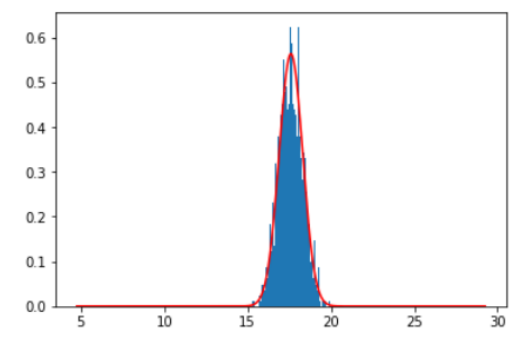

**Figure 1:** A histogram of an approximate probability density function, with a normal distribution plotted on top.


| Parameter | Value |
|:---|---:|
| $T$ | 1.75 |
| $\sigma$ | 0.3 |
| $\alpha$ | 0.4 |
| $X_{init}$ | 17 |
| Number of simulations | 1000, 10000, 100000 |
| Number of timesteps ($N$) | 300 |

**Table 1:** Data to be used in your simulations of discrete walks on a lattice.


Your code must be *vectorized* for efficiency, i.e., prefer vector operations instead of scalar operations.
As a very simple example of vectorization, if I have a Numpy vector $V$ and I want to
add 1 to every entry of the vector, I can simply write the vector operation $V=V+1$, instead
of using a slower for loop over index $i$ and separately computing $V[i]=V[i]+1$ for each entry.
Similarly, many Numpy functions work on vectors rather than single numbers.

Specifically, your code for the lattice walk should only explicitly loop over the timesteps, not
over the individual simulations - for each time step, the updates for all the simulations (within a
set) should be computed together using vector operations. Also, you should not store the entire
lattice at once, but rather only one or two columns of it, to save on memory. The example lattice
walk code in the course notes is likely to be *very helpful*, since it illustrates both vectorization
and lattice walk implementation! (Course notes, page 17).

In addition to the NumPy functions mentioned previously above, you may also find the *mean*,
*std*, and `random.uniform` functions useful.

In a markdown cell in your Jupyter notebook, describe what you observe about your results
(plots and statistics) as the number of simulations increases from 1000 to 100,000.


### Answer — code and results


In [97]:
import numpy as np

T = 1.75
sigma = 0.3
alpha = 0.4
X_init = 17.0
N = 300
sims = [1000,10000,100000]

dt = T / N
p = (1 / 2) * (1 + np.sqrt(dt) * alpha / sigma)
dh = sigma * np.sqrt(dt)

anticipated_mean = X_init + alpha * T
anticipated_std = sigma * np.sqrt(T)

xs = [np.full(sims[i], X_init) for i in range(len(sims))]

In [98]:
for i in range(len(sims)):
    ts = np.linspace(0, T, N)
    for t in ts:
        xs[i] += np.random.choice([dh,-dh],sims[i],p=[p,(1-p)])
    simulated_mean = np.mean(xs[i])
    simulated_std = np.std(xs[i])

    print(f"Run {i+1} ({sims[i]} simulations): ")
    print(f"\t- Anticipated mean: {anticipated_mean:.3f} \t Anticiaped std: {anticipated_std:.3f}")
    print(f"\t- Simulated mean: {simulated_mean:.3f} \t Simulated std: {simulated_std:.3f}")


Run 1 (1000 simulations): 
	- Anticipated mean: 17.700 	 Anticiaped std: 0.397
	- Simulated mean: 17.728 	 Simulated std: 0.396
Run 2 (10000 simulations): 
	- Anticipated mean: 17.700 	 Anticiaped std: 0.397
	- Simulated mean: 17.705 	 Simulated std: 0.397
Run 3 (100000 simulations): 
	- Anticipated mean: 17.700 	 Anticiaped std: 0.397
	- Simulated mean: 17.699 	 Simulated std: 0.395


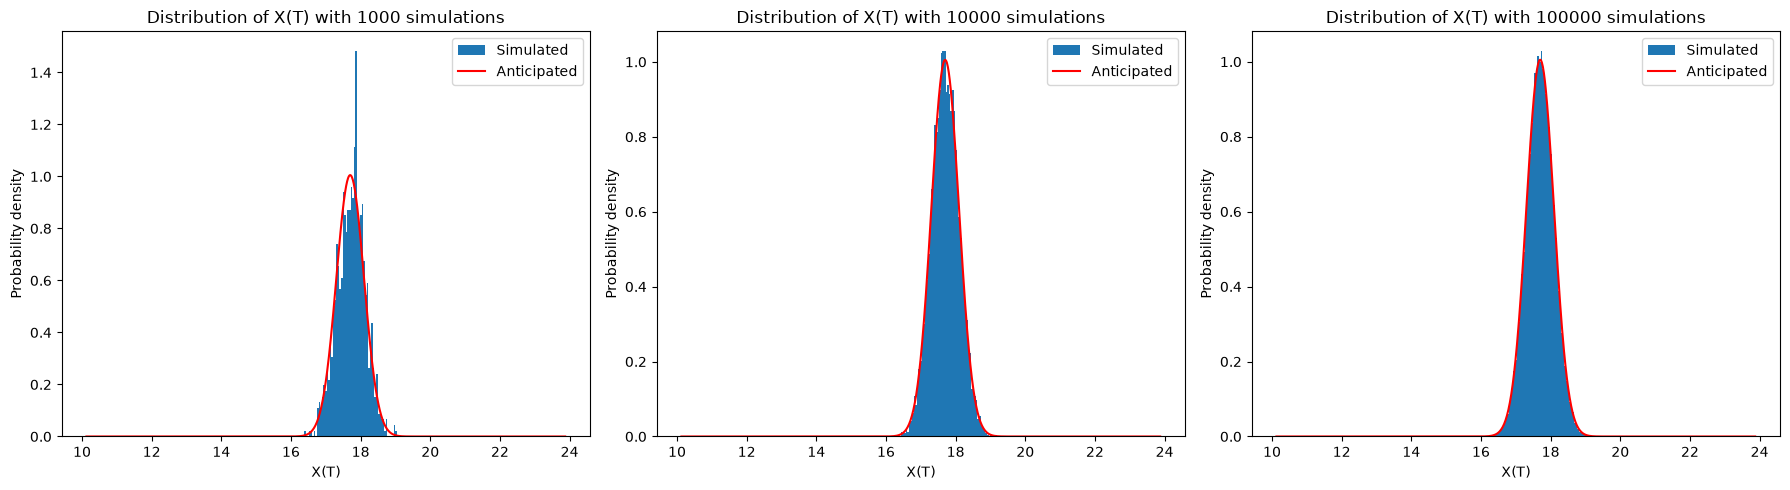

In [99]:
import matplotlib.pyplot as plt
from scipy.stats import norm

fig, axs = plt.subplots(1,len(sims), figsize=(6 * len(sims), 5))

min_X = X_init - N * dh
max_X = X_init + N * dh 

x = np.linspace(min_X, max_X, 1000)
y = norm.pdf(x, loc=anticipated_mean, scale=anticipated_std)

bin_edges = np.linspace( min_X - dh, max_X + dh, N + 2)

for i in range(len(sims)):
    axs[i].set_title(f"Distribution of X(T) with {sims[i]} simulations")
    axs[i].set_xlabel("X(T)")
    axs[i].set_ylabel("Probability density")

    axs[i].hist(xs[i], bins=bin_edges, density = True, label = "Simulated")
    axs[i].plot(x,y,"r",label="Anticipated")

    axs[i].legend(loc="upper right")
plt.tight_layout()
plt.show()

### Answer — observations

For the statistics regarding the simulated man and std vs the anticipated ones, we observe that even with 1000 simulations we get results that are already within $\pm 5\%$ of the anticipated ones. However, as the number of simulations increase, our results are even closer.

Same idea for the plots basically. As the number of simulations increase, our simulated values get close and closer to representing the exact distirbution

## Question 3 — **(6 marks)** Coding: Brownian motion and Ito calculus.


Let

$$
\begin{aligned}
\Delta Z_i&=\phi(t_i)\sqrt{\Delta t}\\
\phi(t_i)&\sim N(0,1)\\
Z(t_0=0)&=0\\
Z(t_i)&=\sum_{j=0}^{i-1}\Delta Z_j\\
t_i&=i\,\Delta t
\end{aligned}
$$

and

$$
\begin{aligned}
I(T,\Delta t)&=\sum_{i=0}^{N-1}(\Delta Z_i)^2\\
\Delta t&=\frac{T}{N}.
\end{aligned}
$$

Write a Jupyter/Python notebook to evaluate $I(T,\Delta t)$. For $T=2$, for fixed $\Delta t$, compute the
value of $I(T,\Delta t)$. Use 70000 paths, and compute the mean and variance of the result, for $N=$
100, 200, 400, 800, 1600, 3200, 6400 timesteps. Vectorize your code so that there is only one
explicit for loop over the timesteps, for a given value of $N$.

Write code to generate a simple text-based table of mean and variance of $I(T,\Delta t)$ for the different
values of $\Delta t$. (No fancy formatting is required! You can just use Python's print function to
generate each row, with appropriate arguments.)

Plot a graph of $\operatorname{var}(I(T,\Delta t))$ versus $\Delta t$, with appropriate labels. In a markdown cell of your
Jupyter notebook, explain mathematically what you observe.


### Answer — code and results


In [100]:
# Add imports and set the parameters for this question here.


In [101]:
# Write your vectorized simulation and print the requested statistics here.


In [102]:
# Generate the requested plots here.


### Answer — observations and mathematical explanation

<!-- Write your discussion here. -->


## Question 4 — **(5 marks)** Ito calculus.


### (a) — 3 marks

Let $X(t)$ and $Y(t)$ be two stochastic processes, such that

$$
\begin{aligned}
dX&=\mu_X(X(t),t)dt+\sigma_X(X(t),t)dZ_X\\
dY&=\mu_Y(Y(t),t)dt+\sigma_Y(Y(t),t)dZ_Y
\end{aligned}
$$

with $dZ_X(t)$, $dZ_Y(t)$ being the increments for two distinct Wiener processes, $Z_X(t)$ and $Z_Y(t)$.
Let $X(t_i)=X_i$ and $Y(t_i)=Y_i$. Show that

$$
\begin{aligned}
(X_{i+1}-X_i)(Y_{i+1}-Y_i)
&=X_{i+1}Y_{i+1}-X_iY_i\\
&\quad-X_i(Y_{i+1}-Y_i)-Y_i(X_{i+1}-X_i).
\end{aligned}
$$


Then, using the definition of the Ito integral which is the limit of a discrete sum, show that

$$
\int_0^t X(s)dY(s)=[XY]_0^t-\int_0^t Y(s)dX(s)-\int_0^t dX(s)dY(s).
$$



**Answer:**

<!-- Write your solution here. -->


### (b) — 2 marks

Let $Z(t)$ be a stochastic process satisfying $dZ=\phi\sqrt{dt}$, and assume $Z(0)=0$.
Using the result in part (a), show that (assuming Ito calculus)

$$
\int_0^t Z(s)\,dZ(s)=\frac12 Z(t)^2-\frac{t}{2}.
$$



**Answer:**

<!-- Write your solution here. -->


## Question 5 — **(10 marks)** Ito calculus and Ito's Lemma.


Suppose $dZ$ is the increment of a Wiener process and

$$
dX=\mu(X(t),t)dt+\sigma(X(t),t)dZ.
$$



### (a) — 6 marks

If

$$
F(X,t)=X^4e^{-t}+3X\cos t,
$$

what is $dF(X,t)$ (interpreted in the sense of Ito calculus)?


**Answer:**

<!-- Write your solution here. -->


### (b) — 4 marks

Using $dX$ as defined above, and expanding, simplify

$$
\int_0^T(dX)^2
$$

as much as possible. The integral is to be interpreted in the Ito calculus sense. (Note that
$\sigma(X(t),t)$ is a function of $t$, not a constant, so you will not be able to fully solve the integral.)


**Answer:**

<!-- Write your solution here. -->
